In [1]:
import sys; sys.path.append("../src")
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

from preprocess import run_pipeline
from features   import fuse_features
from model      import (build_lstm_autoencoder, build_cnn_classifier,
                        build_hybrid_model, create_sequences)
from anomaly    import (compute_reconstruction_error, determine_threshold,
                        flag_anomalies, plot_reconstruction_error)

TIMESTEPS  = 30
BATCH_SIZE = 64
EPOCHS     = 50

In [2]:
import pandas as pd
from preprocess import (load_raw, drop_irrelevant, handle_missing,
                        remove_outliers_iqr, encode_type_column,
                        normalise, SENSOR_COLS, TARGET_COL)

df = load_raw()
df = drop_irrelevant(df)
df = handle_missing(df)
df = remove_outliers_iqr(df, SENSOR_COLS)
df = encode_type_column(df)
df = normalise(df, fit=True)
df = fuse_features(df)                  # ← adds 17 new engineered features

print(f"Total features after fusion: {df.shape[1] - 1}")
df.head(2)

Loaded 10000 rows, 14 columns
Missing values handled.
Outliers clipped.
Scaler saved to outputs/scaler.pkl
Total features after fusion: 25


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,type_H,type_L,type_M,Air temperature [K]_roll_mean,...,Rotational speed [rpm]_roll_std,Rotational speed [rpm]_roll_max,Torque [Nm]_roll_mean,Torque [Nm]_roll_std,Torque [Nm]_roll_max,Tool wear [min]_roll_mean,Tool wear [min]_roll_std,Tool wear [min]_roll_max,temp_delta,power_W
0,0.304348,0.358025,0.378833,0.535714,0.000000,0,False,False,True,0.304348,...,0.000000,0.378833,0.535714,0.000000,0.535714,0.000000,0.000000,0.000000,0.053677,0.021252
1,0.315217,0.370370,0.237389,0.583791,0.011858,0,False,True,False,0.309783,...,0.100016,0.378833,0.559753,0.033996,0.583791,0.005929,0.008385,0.011858,0.055153,0.014513


In [11]:
feature_cols = [c for c in df.columns if c != TARGET_COL]
X = df[feature_cols].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)

print(f"Before SMOTE — failure rate: {y.mean():.4f}")
print(f"Class counts: {np.bincount(y.astype(int))}")

smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X, y)

print(f"After SMOTE  — failure rate: {y_res.mean():.4f}")
print(f"Class counts after SMOTE: {np.bincount(y_res.astype(int))}")

Before SMOTE — failure rate: 0.0339
Class counts: [9661  339]
After SMOTE  — failure rate: 0.5000
Class counts after SMOTE: [9661 9661]


In [12]:


from sklearn.model_selection import train_test_split

X_seq, y_seq = create_sequences(X_res, y_res, TIMESTEPS)
print(f"Total sequences: {len(X_seq)}")
print(f"Class counts in sequences: {np.bincount(y_seq.astype(int))}")

# Stratified split — guarantees both classes in every split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

N_FEATURES = X_seq.shape[2]
print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train failures: {y_train.sum().astype(int)}")
print(f"Val   failures: {y_val.sum().astype(int)}")
print(f"Test  failures: {y_test.sum().astype(int)}  ← must be > 0")

Total sequences: 19292
Class counts in sequences: [9631 9661]

Train: (13503, 30, 25), Val: (1930, 30, 25), Test: (3859, 30, 25)
Train failures: 6762
Val   failures: 966
Test  failures: 1933  ← must be > 0


In [5]:
# Train ONLY on normal samples — this is intentional.
# The autoencoder learns what "normal" looks like.
# It will fail to reconstruct anomalies → high MSE → anomaly alert.

normal_mask = y_train == 0
X_normal = X_train[normal_mask]

ae_model = build_lstm_autoencoder(TIMESTEPS, N_FEATURES)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=3, verbose=1)
]

ae_history = ae_model.fit(
    X_normal, X_normal,           # autoencoder: input = target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

ae_model.save("../outputs/lstm_autoencoder.keras")
print("Autoencoder saved.")

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 0.0897 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0362 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0324 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0313 - val_loss: 0.0314 - learning_rate: 0.0010
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0311 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0296 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 7/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0278 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 8/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0274 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 9/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0270 - val_loss: 0.0273 - learning_rate: 0.0010


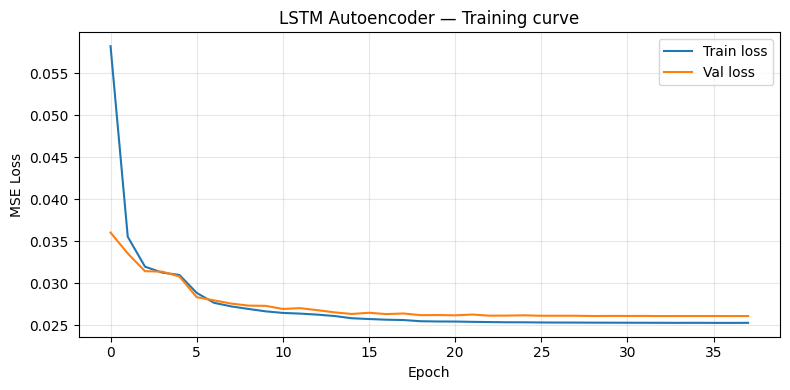

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(ae_history.history["loss"],     label="Train loss")
plt.plot(ae_history.history["val_loss"], label="Val loss")
plt.title("LSTM Autoencoder — Training curve")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/ae_training_curve.png", dpi=150)
plt.show()

Anomaly threshold (p95): 0.029842


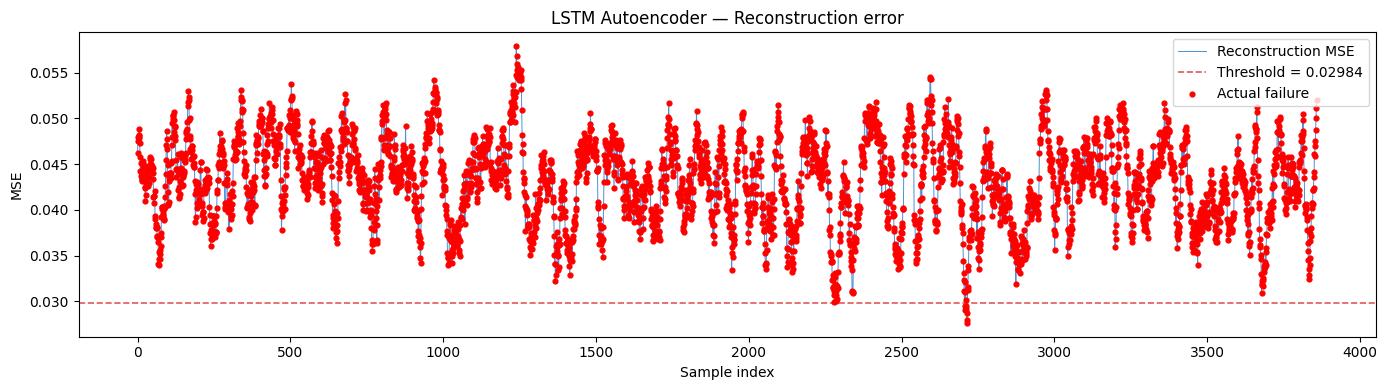

In [7]:
train_errors = compute_reconstruction_error(ae_model, X_normal)
threshold    = determine_threshold(train_errors, percentile=95)

# Evaluate on test set
test_errors      = compute_reconstruction_error(ae_model, X_test)
anomaly_preds_ae = flag_anomalies(test_errors, threshold)

plot_reconstruction_error(
    test_errors, threshold, y_test,
    save_path="../outputs/reconstruction_error.png"
)

In [8]:
hybrid_model = build_hybrid_model(TIMESTEPS, N_FEATURES)

# Class weights compensate for remaining imbalance after SMOTE
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f"Class weights: {class_weight}")

callbacks_cls = [
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=8,
                                  restore_best_weights=True, mode="max"),
    keras.callbacks.ModelCheckpoint("../outputs/hybrid_best.keras",
                                    monitor="val_auc", save_best_only=True,
                                    mode="max")
]

history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks_cls,
    verbose=1
)

Class weights: {0: 1.0, 1: 2.261860028182245}
Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8013 - auc: 0.8939 - loss: 0.5087 - precision: 0.6636 - recall: 0.8792 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 4.5190e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9616 - auc: 0.9727 - loss: 0.2272 - precision: 0.9569 - recall: 0.9165 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 7.2038e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9761 - auc: 0.9800 - loss: 0.1753 - precision: 0.9975 - recall: 0.9247 - val_accuracy: 0.9955 - val_auc: 0.0000e+00 - val_loss: 0.0113 - val_precision: 1.0000 - val_recall: 0.9955
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9747 - auc: 0.9790 - loss: 0.1830 - precision: 0.9980 - recall: 0.9187 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.3194e-0

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Using threshold: 0.5
Predicted — Normal: 1970, Failure: 1889
Actual    — Normal: 1926, Failure: 1933

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      1926
     Failure       0.99      0.97      0.98      1933

    accuracy                           0.98      3859
   macro avg       0.98      0.98      0.98      3859
weighted avg       0.98      0.98      0.98      3859

ROC-AUC: 0.9905


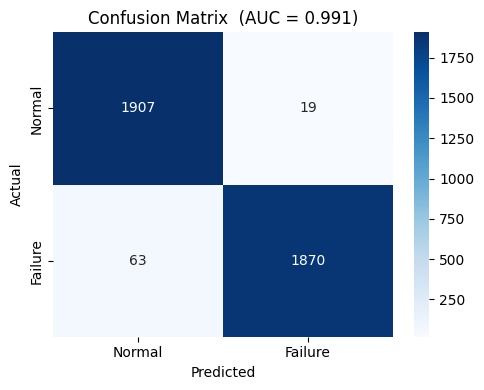

In [13]:


y_prob = hybrid_model.predict(X_test, batch_size=BATCH_SIZE).ravel()

# Try multiple thresholds and pick the one that gives predictions for both classes
for thresh in [0.5, 0.4, 0.3, 0.2, 0.1]:
    preds = (y_prob >= thresh).astype(int)
    if len(np.unique(preds)) == 2:
        print(f"Using threshold: {thresh}")
        y_pred = preds
        break
else:
    y_pred = (y_prob >= 0.1).astype(int)
    print("Warning: model still predicts mostly one class")

print(f"Predicted — Normal: {(y_pred==0).sum()}, Failure: {(y_pred==1).sum()}")
print(f"Actual    — Normal: {(y_test==0).sum().astype(int)}, Failure: {(y_test==1).sum().astype(int)}")

print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Failure"],
    labels=[0, 1],
    zero_division=0
))

# ROC-AUC — only works if both classes are in y_test
if len(np.unique(y_test)) == 2:
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {auc:.4f}")
else:
    auc = 0.0
    print("ROC-AUC: Not defined — only one class in test set")

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Normal", "Failure"],
            yticklabels=["Normal", "Failure"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix  (AUC = {auc:.3f})")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()

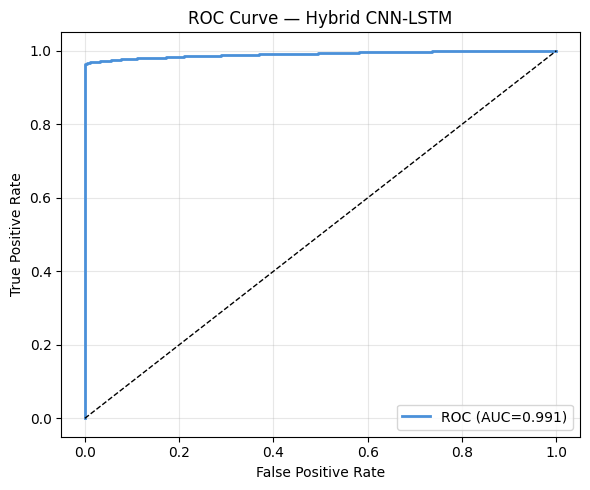

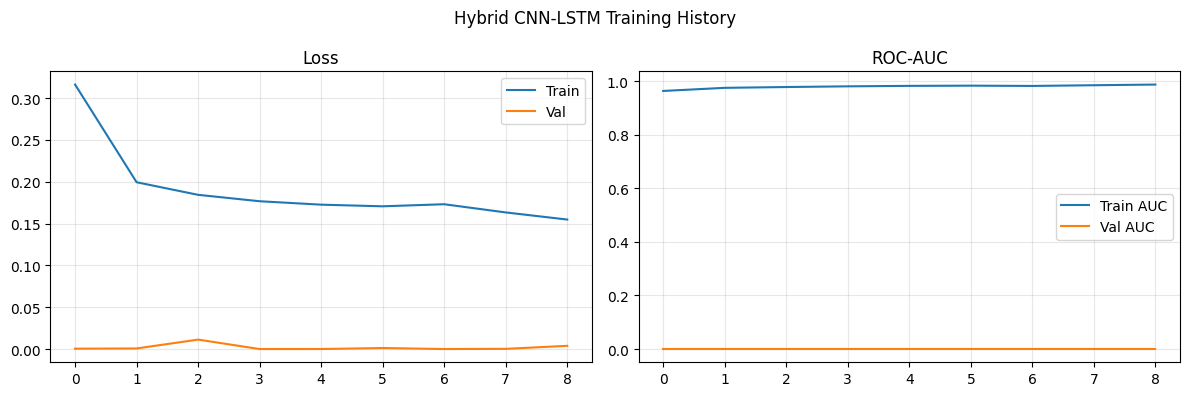

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4A90D9", lw=2, label=f"ROC (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hybrid CNN-LSTM")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/roc_curve.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history["auc"],     label="Train AUC")
axes[1].plot(history.history["val_auc"], label="Val AUC")
axes[1].set_title("ROC-AUC"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Hybrid CNN-LSTM Training History")
plt.tight_layout()
plt.savefig("../outputs/training_history.png", dpi=150)
plt.show()